<a href="https://colab.research.google.com/github/MariaDelSolMM13/My-Website-Maria-Del-Sol-Munoz-Mortera/blob/main/Proyecto_Final_Diplomado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Título del Proyecto:** ¿Por qué no crecemos para siempre? La ciencia de la Ecuación Logística



**Nombre:** María del Sol Muñoz Mortera


**Lenguaje de Programación del Proyecto Final**: Python


**OBJETIVOS**

* **Objetivo General:** Presentar como recurso didáctico en la enseñanza de la ecuación logística poblacional, su uso, características y limitantes a través de un script en Python, que muestre visualmente la gráfica que caracteriza esta ecuación.
* **Objetivo particular 1:** Demostrar visualmente la función de crecimiento logístico poblacional, teniendo aplicación, en biología, química, ecología, etc.
* **Objetivo particular 2:** Hacer uso como herramienta de programación con Python para mostrar como funciona la ecuación logística poblacional.





**INTRODUCCIÓN**

Dinámica de poblaciones con restricción ambiental.
En términos científicos, esto se conoce como **Crecimiento logístico**.
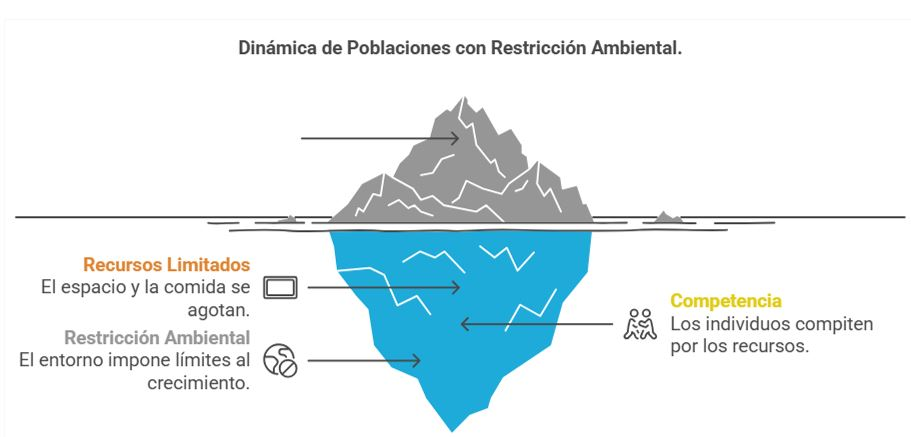


**CONCEPTOS CLAVE:**

La Matemática detrás (Modelo Logístico)

Para describir esto formalmente, utilizamos la Ecuación logística (o ecuación de Verhulst).

```
dN/dt = rN (1-N/K)
```
Donde:

dN/dt: Es la velocidad de crecimiento de la población en un momento dado.

r: Es la capacidad biológica máxima de reproducción por individuo cuando no hay estrés ambiental (recursos ilímitados).

N: Es la población actual.

K: Es la capacidad de carga.


El término `(1-N/K)` :

* Si N es muy pequeño (poca gente), el término es casi 1, y la población crece rápido (como si fuera exponencial).
* Si N se acerca a K (casa llena), el término se acerca a 0, y el crecimiento se detiene.


**¿Qué pasa en el mundo real?**

En la realidad, las poblaciones rara vez se quedan perfectamente quietas en la línea de K y suelen ocurrir dos cosas:
* Oscilaciones: La población sube un poco por encima de K y luego baja un poco por debajo, fluctuando constantemente alrededor del límite.

* Sobrepaso y colapso (Overshoot): Si una población crece demasiado rápido y consume los recursos antes de que estos se regeneren, puede superar K drásticamente. Esto daña el medio ambiente, reduciendo la capacidad de carga futura y provocando una caída brusca de la población.


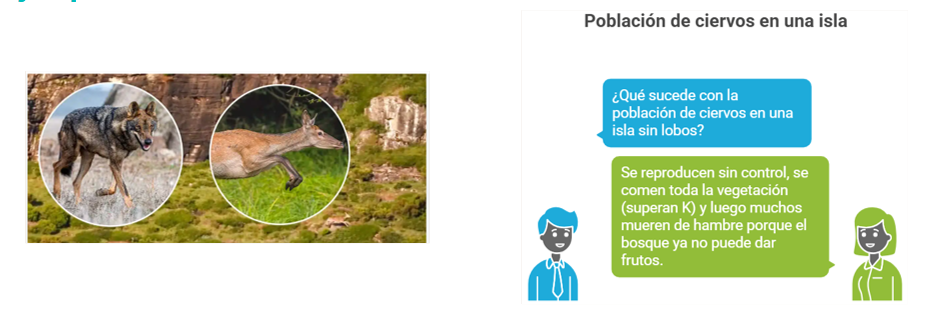

**DEMOSTRACIÓN MATEMÁTICA**

---



[Revisión del Artículo:](https://www.redalyc.org/pdf/636/63613123024.pdf)

“El modelo logístico: Una alternativa para el estudio del crecimiento poblacional de organismos”, (Ulloa Ibarra y Rodríguez Carrillo, 2010).


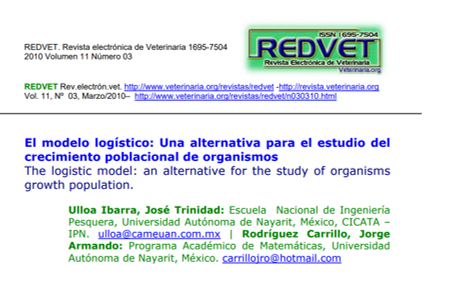



---



 **DEFINICIÓN DEL MODELO:**

(usando la formula integrada  en lugar de la diferencial, teniendo lo siguiente:

Modelo integrado:

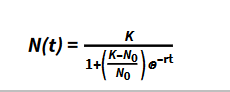

**Factores N(t), t y e**

  N(t) representa el número de organismos en un "t" determinado. Mientras que, "e" es la base del logaritmo natural,  aproximadamente 2.7183.

**Parámetro K**
Es la capacidad de carga del ambiente, teóricamente es el valor que determina la línea ó nivel de saturación del sistema, sin embargo, en la práctica la densidad no suele nivelarse en un estado estable inmediatamente debajo de K, si no que fluctúa arriba y abajo de los niveles (Odum y Sarmiento, 1998) ya que no existen controles hemostáticos puntuales por encima del nivel jerárquico de los organismos.

```
De esta forma si:

                 lim(t→∞)⁡〖N(t)=K〗
```



**Parámetro `N0`**

Determina la población inicial que representa el sistema. La población inicial deberá ser menor que la capacidad de carga teórica del ambiente, la población máxima. Por otro lado, nunca habrá `N0=0`, dado que debe existir una población base para este presente un crecimiento en ella y por lo que pueda desarrollarse un crecimiento logístico que exprese su crecimiento poblacional. Así pues, tampoco puede existir `N0=K`


**Relación entre los parámetros` K `y `N0`**

Si `N0<K `la población crece, hasta verse afectada por los diversos factores del medio ambiente, y alcanza su nivel de saturación o capacidad de carga `K`.

**Parámetro `r`**

El parámetro` r` representa en la función logística, la tasa instantánea de crecimiento poblacional. A diferencia de la función exponencial, el parámetro `r` en la función logística no es constante, el estatus del parámetro, en la función logística.


**Capacidad de carga media `K/2`**

Punto de Máximo Crecimiento Poblacional: En la curva de crecimiento logístico, el punto donde la población alcanza `K/2` es el momento en que la tasa de crecimiento de la población `(dN/dt)` es máxima.

**Librerias que utilizaremos:**

* import numpy as np
* import matplotlib.pyplot as plt
* import ipywidgets as widgets
* from ipywidgets import interact, FloatSlider, IntSlider, Dropdown, Layout
* from IPython.display import display, clear_output



---



# **DEMOSTRACIÓN**

---



🔻**Importación de Librerías y Definición de Fórmulas**

Primero, definimos las funciones matemáticas basándonos en las ecuaciones logística y de velocidad descritas anteriormente.

In [ ]:
#--------------------------------------
# INSTALACIÓN DE LIBRERIAS
#--------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown, Layout
from IPython.display import display, clear_output

#--------------------------------------
# Configuración de estilo para gráficos
#--------------------------------------
plt.style.use('seaborn-v0_8-whitegrid')

#--------------------------------------
# DEFINICIÓN DE FUNCIONES MATEMÁTICAS
#--------------------------------------

# Definición del modelo Formula integrada: N(t) = K / (1 + ((K - N0) / N0) * e^(-rt))
def logistica_N(t, r, K, n0):
    """
    Calcula la población en el tiempo t.
    """
    return K / (1 + ((K - n0) / n0) * np.exp(-r * t))

# Comprobación de la ecuación de Verhulst: dN/dt = rN(1 - N/K)
def velocidad_log(n, r, K):
    """
    Calcula la velocidad de crecimiento instantánea.
    """
    return r * n * (1 - n / K)
#--------------------------------------

🔻**Gráfico Estático - Efecto de "r" vs Velocidad**

En este bloque, comparamos cómo las diferentes tasas de crecimiento afectan la curva de crecimiento (Lento, Medio, Rápido).


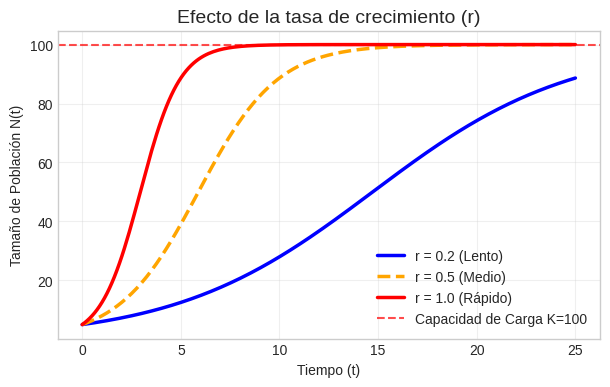

In [ ]:
# --------------------------------------------------------------------------
# 1. Familia de curvas (efecto de "r" tasa instantánea de crecimiento poblacional)
# --------------------------------------------------------------------------

#--------------------------------------
# Declaración de parámetros:
#--------------------------------------
def plot_efecto_r():

    # Parámetros fijos Para evaluar la ecuación
    K_val = 100 # Capacidad de carga
    n0_val = 5  # Población inicial
    tiempo_max = 25
    t = np.linspace(0, tiempo_max, 200)

    # Tasas a evaluar de r (Lento, Medio, Rápido)
    tasas = [0.2, 0.5, 1.0]
    colores = ['blue', 'orange', 'red']
    etiquetas = ['r = 0.2 (Lento)', 'r = 0.5 (Medio)', 'r = 1.0 (Rápido)']

#--------------------------------------
# Generación de los Gráficos
#--------------------------------------
    plt.figure(figsize=(7, 4))

    # Generar curvas de r (Lento, Medio, Rápido)
    for r, color, label in zip(tasas, colores, etiquetas):
        N = logistica_N(t, r, K_val, n0_val) # Evaluando la Ecuacion
        estilo = '--' if r == 0.5 else '-'

        # Línea punteada
        plt.plot(t, N, label=label, color=color, linestyle=estilo, linewidth=2.5)

    # Línea de Capacidad de Carga K (nivel de saturación)
    plt.axhline(y=K_val, color='red', linestyle='--', alpha=0.7, label=f'Capacidad de Carga K={K_val}')

    # Generación de Leyendas en el gráfico
    plt.title('Efecto de la tasa de crecimiento (r)', fontsize=14)
    plt.xlabel('Tiempo (t)')
    plt.ylabel('Tamaño de Población N(t)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_efecto_r()
#--------------------------------------

🔻**Simulador Interactivo: Efecto de la Velocidad de crecimiento**



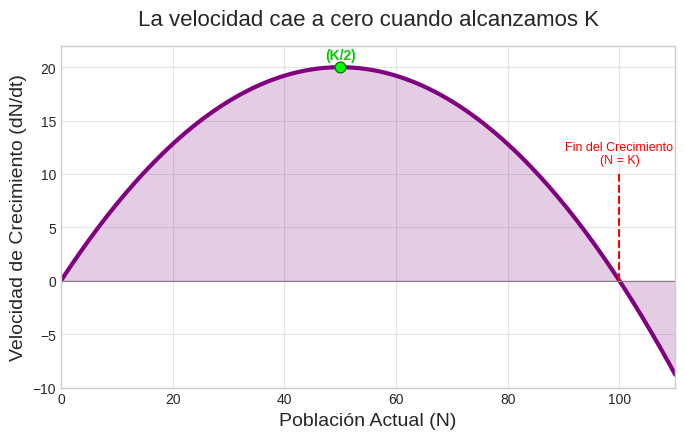

In [ ]:
# --------------------------------------------------------------------------
# 3. Efecto de la Veocidad de Crecimiento
# --------------------------------------------------------------------------

#--------------------------------------
# Configuración de Parámetros
#--------------------------------------
r_demo = 0.8   # Tasa instantanea de crecmiento poblacional
K_demo = 100   # Capacidad de Carga/nivel de saturación

def velocidad(n):
    return r_demo * n * (1 - n / K_demo)

# --------------------------------------------------------------------------
# Generación del Gráfico
# --------------------------------------------------------------------------

# Generamos datos hasta 110 para ver la zona negativa
n_vals = np.linspace(0, 110, 200)
v_vals = velocidad(n_vals)


plt.figure(figsize=(7, 4.5))

# Trazar la curva y el relleno
plt.plot(n_vals, v_vals, color='purple', linewidth=3)
plt.fill_between(n_vals, v_vals, 0, color='purple', alpha=0.2)

# Añadir una línea sutil en el 0 para referencia visual
plt.axhline(0, color='gray', linewidth=0.8)

# --------------------------------------------------------------------------
# Marcadores y Estilos
# --------------------------------------------------------------------------

# --- Punto Máximo (K/2) --- Punto máximo de crecimiento poblacional
k_half = K_demo / 2
v_max = velocidad(k_half)

# Punto Verde brillante
plt.scatter([k_half], [v_max], color='#00FF00', s=60, zorder=5, edgecolors='green')

# Texto en verde (encima del punto)
plt.text(k_half, v_max + 0.5, "(K/2)", color='#00CC00', ha='center', va='bottom', fontweight='bold')

# Línea K (Fin del crecimiento)
# Línea roja punteada
plt.vlines(x=K_demo, ymin=0, ymax=10, colors='red', linestyles='dashed', linewidth=1.5)

# Texto en rojo
plt.text(K_demo, 11, "Fin del Crecimiento\n(N = K)", color='red', ha='center', fontsize=9)

# --------------------------------------------------------------------------
# Títulos y Etiquetas
# --------------------------------------------------------------------------

# Título y Etiquetas grandes
plt.title("La velocidad cae a cero cuando alcanzamos K", fontsize=16, pad=15)
plt.xlabel("Población Actual (N)", fontsize=14)
plt.ylabel("Velocidad de Crecimiento (dN/dt)", fontsize=14)

# Grid
plt.grid(True, linestyle='-', alpha=0.5)

# Definir los límites para ver los negativos
plt.xlim(0, 110)   # Eje X un poco más allá de 100
plt.ylim(-10, 22)  # Eje Y desde -10 para ver la "cola" negativa

plt.tight_layout()
plt.show()



---



🔻**MODELO INTERACTIVO UNIFICADO. Población vs Velocidad**

En este bloque se presentan los diferentes parámetros al mismo tiempo para conocer como se afectan entre sí.



In [ ]:
# ---------------------------------------------------------
# 4. Modelo interactivo unificado (población vs velocidad)
# ---------------------------------------------------------

#--------------------------------------
# Ecuaciones:
#--------------------------------------
def logistica_N(t, r, K, n0):
    """Calcula la población N en el tiempo t."""
    exp_term = np.exp(-r * t)
    return K / (1 + ((K - n0) / n0) * exp_term)

def velocidad_inst(n, r, K):
    """Calcula la velocidad dN/dt basada en la población actual n."""
    return r * n * (1 - n / K)

#--------------------------------------
# Generación del gráfico de Visualización Principal
#--------------------------------------
def plot_simulation(r, K, n0, tiempo_sim, tiempo_actual):

    # Cálculos del estado actual (Punto Negro)
    N_actual = logistica_N(tiempo_actual, r, K, n0)
    Vel_actual = velocidad_inst(N_actual, r, K)

    # Configuración del lienzo (2 Gráficos lado a lado)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

    # --- GRÁFICO 1: La Historia en el Tiempo (Sigmoide) ---
    t_vals = np.linspace(0, tiempo_sim, 200)
    N_vals = logistica_N(t_vals, r, K, n0)

    ax1.plot(t_vals, N_vals, color='#0080CC', linewidth=3) # Azul

    # Línea de Capacidad K
    ax1.hlines(y=K, xmin=0, xmax=tiempo_sim, colors='red', linestyles='dashed')
    ax1.text(tiempo_sim * 0.05, K + 5, "K", color='red', fontweight='bold', fontsize=12)

    # Punto dinámico (Tiempo vs N)
    ax1.scatter([tiempo_actual], [N_actual], color='black', s=100, zorder=5)

    # Formato de Etiquetas Gráfico 1
    ax1.set_xlim(0, tiempo_sim)
    ax1.set_ylim(0, 200) # Rango fijo
    ax1.set_xlabel("Tiempo (t)")
    ax1.set_ylabel("Población (N)")
    ax1.set_title("Crecimiento Poblacional")
    ax1.grid(True, alpha=0.3)

    # --- GRÁFICO 2: La Mecánica del Cambio (Parábola) ---
    n_space = np.linspace(0, 200, 200) # Rango fijo en X hasta 200
    vel_vals = velocidad_inst(n_space, r, K)

    ax2.plot(n_space, vel_vals, color='purple', linewidth=3)
    ax2.fill_between(n_space, vel_vals, color='purple', alpha=0.2)

    # Línea Verde: El óptimo K/2
    k_half = K / 2
    ax2.vlines(x=k_half, ymin=0, ymax=60, colors='green', linestyles='dashed')
    ax2.text(k_half, 55, "K/2", color='darkgreen', fontweight='bold', ha='center', backgroundcolor='white')

    # Punto dinámico (N vs Velocidad)
    # Nótese que aquí el eje X es la Población N_actual, no el tiempo
    ax2.scatter([N_actual], [Vel_actual], color='black', s=120, zorder=5)

    # Formato de Etiquetas Gráfico 2
    ax2.set_xlim(0, 200)
    ax2.set_ylim(0, 60) # Rango fijo en Y
    ax2.set_xlabel("Población (N)")
    ax2.set_ylabel("Velocidad (dN/dt)")
    ax2.set_title("Velocidad de cambio")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# Controles (Widgets)
# ---------------------------------------------------------

# Parámetros Biológicos
style_desc = {'description_width': 'initial'}
w_r = widgets.FloatSlider(value=0.5, min=0.1, max=2.0, step=0.1, description='Tasa (r)', style=style_desc)
w_K = widgets.IntSlider(value=100, min=50, max=180, step=10, description='Capacidad (K)', style=style_desc)
w_n0 = widgets.IntSlider(value=10, min=1, max=50, step=1, description='Población Inicial', style=style_desc)

# Simulación (Tiempo)
w_time_sim = widgets.IntSlider(value=30, min=10, max=50, step=5, description='Eje de Tiempo', style=style_desc)
w_time_act = widgets.FloatSlider(value=0, min=0, max=30, step=0.5, description='Simular Tiempo', style=style_desc)

# Lógica para vincular el máximo del slider de "Simular Tiempo" con el "Eje de Tiempo"

def update_time_limit(*args):
    w_time_act.max = w_time_sim.value
    if w_time_act.value > w_time_sim.value:
        w_time_act.value = w_time_sim.value

w_time_sim.observe(update_time_limit, 'value')

# Organización Visual (Layout)
# Columna izquierda: Controles
controls_box = widgets.VBox([
    widgets.HTML("<b>Parámetros Biológicos</b>"),
    w_r, w_K, w_n0,
    widgets.HTML("<hr><b>Simulación</b>"), # Delimiter simulado con HTML
    w_time_sim, w_time_act
])

# Output interactivo
out = widgets.interactive_output(plot_simulation, {
    'r': w_r,
    'K': w_K,
    'n0': w_n0,
    'tiempo_sim': w_time_sim,
    'tiempo_actual': w_time_act
})
#--------------------------------------
# Mostrar todo junto
#--------------------------------------
display(widgets.VBox([controls_box, out]))
#--------------------------------------

🔻**Escenarios Multi-Especie (Bacterias, Ballenas, Humanos)**

Se genera un panel donde se puede interactuar y simular a futuro, el ¿Por qué no crecemos para siempre?



In [ ]:
# ---------------------------------------------------------
# 5. Modelo Multi-Especie (Bacterias, Ballenas, Humanos)
# ---------------------------------------------------------


# ---------------------------------------------------------
# Definición de Funciones Matemáticas (Modelo Logístico)
# ---------------------------------------------------------
def logistica_N(t, r, K, n0):
    """Calcula la población N en el tiempo t."""
    # Evitamos división por cero o exponentes extremos
    exp_term = np.exp(-r * t)
    return K / (1 + ((K - n0) / n0) * exp_term)

def velocidad_log(n, r, K):
    """Calcula la velocidad instantánea dN/dt."""
    return r * n * (1 - n / K)

# ---------------------------------------------------------
# Configuración de Estilos y Colores
# ---------------------------------------------------------

# Diccionario
colores = {
    "Bacteria": "#32CD32",  # Verde
    "Ballena": "#0066CC",   # Azul
    "Humano": "#CC6600"     # Naranja/Marrón
}

plt.style.use('default')

# ---------------------------------------------------------
# Funciones de Visualización para cada Escenario
# ---------------------------------------------------------

def plot_bacterias(r, K, n0, max_time, t_actual):
    # Generar datos
    t_vals = np.linspace(0, max_time, 200)
    N_vals = logistica_N(t_vals, r, K, n0)

    # Valores actuales
    N_now = logistica_N(t_actual, r, K, n0)
    vel_now = velocidad_log(N_now, r, K)
    freno = 1 - (N_now / K)

    # Configuración de figura
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.patch.set_facecolor('#FFFFE0') # LightYellow

    # Gráfico 1: N vs t
    ax1.plot(t_vals, N_vals, color=colores["Bacteria"], linewidth=3)
    ax1.axhline(K, color='red', linestyle='--', label='K (Capacidad)')
    ax1.scatter([t_actual], [N_now], color='black', s=100, zorder=5)
    ax1.set_title("Curva de Crecimiento")
    ax1.set_xlabel("Tiempo (Horas)")
    ax1.set_ylabel("Millones de Bacterias")
    ax1.set_ylim(0, K * 1.2)
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Gráfico 2: Velocidad vs N
    n_axis = np.linspace(0, K * 1.1, 200)
    v_axis = velocidad_log(n_axis, r, K)
    ax2.plot(n_axis, v_axis, color='purple', linewidth=3)
    ax2.fill_between(n_axis, v_axis, color='purple', alpha=0.1)
    ax2.scatter([N_now], [vel_now], color='black', s=100, zorder=5)
    ax2.set_title("Velocidad de Reproducción")
    ax2.set_xlabel("Población (N)")
    ax2.set_ylabel("Velocidad (Millones/hora)")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Panel de Texto Dinámico
    estado = "¡CUIDADO! Nutrientes agotándose, crecimiento casi nulo." if freno < 0.15 else "Crecimiento activo."
    color_estado = "red" if freno < 0.15 else "green"

    print(f"\n--- Análisis Matemático en t = {t_actual:.1f} horas ---")
    print(f"Población Actual (N) = {N_now:.0f} millones")
    print(f"Factor de Freno (1 - N/K) = (1 - {N_now:.0f}/{K}) = {freno:.3f}")
    print(f"Velocidad dN/dt = {vel_now:.0f} millones/hora")
    print(f"ESTADO: {estado}")


def plot_ballenas(r, K, n0, max_time, t_actual):
    t_vals = np.linspace(0, max_time, 200)
    N_vals = logistica_N(t_vals, r, K, n0)

    N_now = logistica_N(t_actual, r, K, n0)
    vel_now = velocidad_log(N_now, r, K)
    freno = 1 - (N_now / K)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.patch.set_facecolor('#E0F7FA') # LightBlue

    # Gráfico 1
    ax1.plot(t_vals, N_vals, color=colores["Ballena"], linewidth=3)
    ax1.axhline(K, color='red', linestyle='--', label='K')
    ax1.scatter([t_actual], [N_now], color='black', s=100, zorder=5)
    ax1.set_title("Recuperación Poblacional")
    ax1.set_xlabel("Tiempo (Años)")
    ax1.set_ylabel("Individuos")
    ax1.set_ylim(0, K * 1.2)
    ax1.grid(True, alpha=0.3)

    # Gráfico 2
    n_axis = np.linspace(0, K * 1.1, 200)
    v_axis = velocidad_log(n_axis, r, K)
    ax2.plot(n_axis, v_axis, color='purple', linewidth=3)
    ax2.fill_between(n_axis, v_axis, color='purple', alpha=0.1)
    ax2.scatter([N_now], [vel_now], color='black', s=100, zorder=5)
    ax2.set_title("Tasa de Crecimiento")
    ax2.set_xlabel("Población (N)")
    ax2.set_ylabel("Nuevas Ballenas/Año")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Texto
    estado = "Población en peligro (muy baja)." if N_now < K * 0.2 else "Población estable o recuperándose."
    print(f"\n--- Análisis en el año {t_actual:.0f} ---")
    print(f"Población Actual (N) = {N_now:.0f} ballenas")
    print(f"Espacio disponible (1 - N/K) = {freno:.3f}")
    print(f"Crecimiento anual = {vel_now:.1f} ballenas/año")
    print(f"ESTADO: {estado}")


def plot_humanos(r, K, n0, max_time, t_actual):
    t_vals = np.linspace(0, max_time, 200)
    N_vals = logistica_N(t_vals, r, K, n0)

    N_now = logistica_N(t_actual, r, K, n0)
    vel_now = velocidad_log(N_now, r, K) # En Mil Millones
    vel_millones = vel_now * 1000 # Convertir a Millones absolutos
    freno = 1 - (N_now / K)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.patch.set_facecolor('#FFE4B5') # LightOrange (Moccasin)

    # Gráfico 1
    ax1.plot(t_vals, N_vals, color=colores["Humano"], linewidth=3)
    ax1.axhline(K, color='red', linestyle='--', label=f'K estimada ({K}MM)')
    ax1.axhline(8, color='gray', linestyle=':', label='Hoy (8MM)')
    ax1.scatter([t_actual], [N_now], color='black', s=100, zorder=5)
    ax1.set_title("Proyección Futura (Humanos)")
    ax1.set_xlabel("Años desde ahora")
    ax1.set_ylabel("Mil Millones (Billions)")
    ax1.set_ylim(0, max(50, K*1.2)) # Ajuste dinámico si K es muy grande
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Gráfico 2
    n_axis = np.linspace(0, 50, 200)
    v_axis = velocidad_log(n_axis, r, K)
    ax2.plot(n_axis, v_axis, color='purple', linewidth=3)
    ax2.fill_between(n_axis, v_axis, color='purple', alpha=0.1)
    ax2.scatter([N_now], [vel_now], color='black', s=100, zorder=5)
    ax2.set_title("Velocidad de Cambio")
    ax2.set_xlabel("Población (Mil M)")
    ax2.set_ylabel("Crecimiento (Mil M/año)")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Texto Lógico
    mensaje = ""
    if K <= 12 and N_now >= 8:
        mensaje = "ESCENARIO PESIMISTA: Estamos chocando con el límite. Crecimiento se frena drásticamente."
    else:
        mensaje = "ESCENARIO OPTIMISTA (Tecnología): Aún hay espacio para crecer. El crecimiento sigue alto."

    print(f"\n--- Debate sobre la Capacidad de Carga (K) ---")
    print(f"Si asumimos K = {K} mil millones:")
    print(f"Población simulada (N) = {N_now:.2f} mil millones")
    print(f"Factor ambiental (1 - N/K) = {freno:.3f}")
    print(f"Tasa de crecimiento resultante = {vel_millones:.0f} millones personas/año")
    print(f"CONCLUSIÓN: {mensaje}")


# ---------------------------------------------------------
# Creación de la Interfaz (Widgets)
# ---------------------------------------------------------

# --- Pestaña 1: Bacterias ---
def ui_bacterias():
    w_r = widgets.FloatSlider(value=3.0, min=1.0, max=5.0, step=0.1, description='Tasa (r)')
    w_K = widgets.IntSlider(value=10000, min=5000, max=20000, step=100, description='Capacidad (K)')
    w_n0 = widgets.IntSlider(value=100, min=10, max=500, step=10, description='Inicial (N0)')
    w_time = widgets.IntSlider(value=10, min=5, max=24, step=1, description='Eje Tiempo')
    w_t_act = widgets.FloatSlider(value=0, min=0, max=24, step=0.1, description='Simular T')

    # Vincular límite de t_actual con w_time
    def update_t_range(*args):
        w_t_act.max = w_time.value
    w_time.observe(update_t_range, 'value')

    ui = widgets.VBox([
        widgets.HTML("<h3>1. Bacterias (E. coli)</h3><p><i>Crecimiento rápido en espacio limitado</i></p>"),
        widgets.HBox([w_r, w_K, w_n0]),
        widgets.HBox([w_time, w_t_act]),
        widgets.interactive_output(plot_bacterias,
                                   {'r': w_r, 'K': w_K, 'n0': w_n0, 'max_time': w_time, 't_actual': w_t_act})
    ])
    return ui

# --- Pestaña 2: Ballenas ---
def ui_ballenas():
    w_r = widgets.FloatSlider(value=0.03, min=0.01, max=0.1, step=0.005, description='Tasa (r)')
    w_K = widgets.IntSlider(value=5000, min=1000, max=10000, step=100, description='Capacidad (K)')
    w_n0 = widgets.IntSlider(value=500, min=100, max=2000, step=50, description='Inicial (N0)')
    w_time = widgets.IntSlider(value=200, min=50, max=500, step=10, description='Horizonte')
    w_t_act = widgets.FloatSlider(value=0, min=0, max=500, step=1, description='Año Actual')

    def update_t_range(*args):
        w_t_act.max = w_time.value
    w_time.observe(update_t_range, 'value')

    ui = widgets.VBox([
        widgets.HTML("<h3>2. Ballenas (Estrategia K)</h3><p><i>Recuperación lenta y estabilidad a largo plazo</i></p>"),
        widgets.HBox([w_r, w_K, w_n0]),
        widgets.HBox([w_time, w_t_act]),
        widgets.interactive_output(plot_ballenas,
                                   {'r': w_r, 'K': w_K, 'n0': w_n0, 'max_time': w_time, 't_actual': w_t_act})
    ])
    return ui

# --- Pestaña 3: Humanos ---
def ui_humanos():
    w_r = widgets.FloatSlider(value=0.01, min=0.005, max=0.03, step=0.001, description='Tasa (r)')
    w_K = widgets.IntSlider(value=10, min=8, max=40, step=1, description='K (Mil M)')
    w_n0 = widgets.FloatSlider(value=8.0, min=6.0, max=10.0, step=0.1, description='N0 (Actual)')
    w_time = widgets.IntSlider(value=100, min=50, max=200, step=10, description='Futuro (Años)')
    w_t_act = widgets.FloatSlider(value=0, min=0, max=200, step=1, description='Avanzar T')

    def update_t_range(*args):
        w_t_act.max = w_time.value
    w_time.observe(update_t_range, 'value')

    ui = widgets.VBox([
        widgets.HTML("<h3>3. Humanos (El debate de K)</h3><p><i>¿Cuál es nuestro límite? Escenarios pesimistas vs optimistas</i></p>"),
        widgets.HBox([w_r, w_K, w_n0]),
        widgets.HBox([w_time, w_t_act]),
        widgets.interactive_output(plot_humanos,
                                   {'r': w_r, 'K': w_K, 'n0': w_n0, 'max_time': w_time, 't_actual': w_t_act})
    ])
    return ui

# ---------------------------------------------------------
# Ejecución Principal (TabView)
# ---------------------------------------------------------
tab = widgets.Tab(children=[ui_bacterias(), ui_ballenas(), ui_humanos()])
tab.set_title(0, 'Bacterias')
tab.set_title(1, 'Ballenas')
tab.set_title(2, 'Humanos')

display(tab)



---



**CONCLUSIONES**

En conclusión, la modelización computacional de la ecuación logística confirma que la sostenibilidad de cualquier sistema biológico depende críticamente de su capacidad de carga ($K$), la cual actúa como un freno natural ante el crecimiento exponencial desmedido por la limitación de recursos. Los resultados de la simulación demuestran que la velocidad máxima de proliferación no es constante, sino que alcanza su pico crítico cuando la población llega a la mitad de su capacidad ($K/2$), momento tras el cual la resistencia ambiental fuerza una desaceleración hacia el equilibrio o, en casos de sobreexplotación ($overshoot$), hacia el colapso poblacional. Por tanto, la integración de herramientas de programación como Python en el análisis ecológico resulta indispensable no solo para visualizar teóricamente estas dinámicas no lineales, sino para predecir escenarios de riesgo donde la demanda biológica supera la regeneración del entorno.